# Part 1: Data Cleaning
Decisions: Imputed Age group-wise to preserve distributions. Capped Fare to reduce skew from high tickets. Cabin dropped after adding indicator due to 77% missing. No inconsistencies or duplicates

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071  

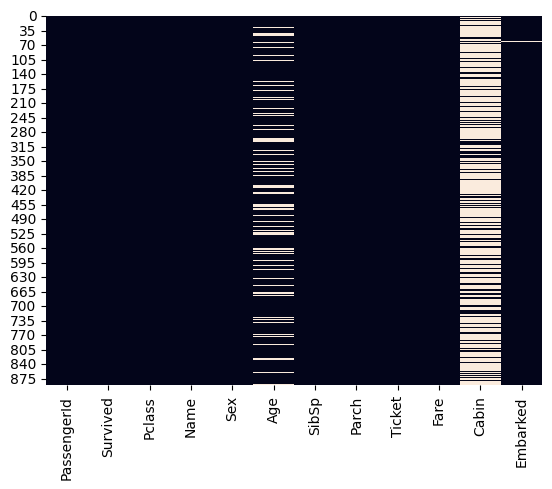

0
<StringArray>
['male', 'female']
Length: 2, dtype: str


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/train.csv')
print(df.info())  # Shows missing: Age 177, Cabin 687, Embarked 2
print(df.describe())  # For outliers: Fare max 512, Age max 80

# Missing values visualization
sns.heatmap(df.isnull(), cbar=False)
plt.show()

# Impute Embarked
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Impute Age with median by Pclass and Sex
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

# Cabin: Add indicator and drop
df['CabinMissing'] = df['Cabin'].isnull().astype(int)
df.drop('Cabin', axis=1, inplace=True)

# Outliers: Cap Fare
fare_cap = df['Fare'].quantile(0.99)  # 263
df['Fare'] = np.where(df['Fare'] > fare_cap, fare_cap, df['Fare'])

# Check duplicates
print(df.duplicated().sum())  # 0

# Consistency: Sex unique values
print(df['Sex'].unique())  # ['male' 'female']

# Save cleaned
df.to_csv('../data/train_cleaned.csv', index=False)

## Part 2: Feature Engineering
Justifications: FamilySize captures group dynamics. Title adds social status info. LogFare reduces skew (original skew ~4.8, log ~0.5). Visuals show larger families had lower survival."

<>:11: SyntaxWarning: invalid escape sequence '\.'
<>:11: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_16156/3144837078.py:11: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


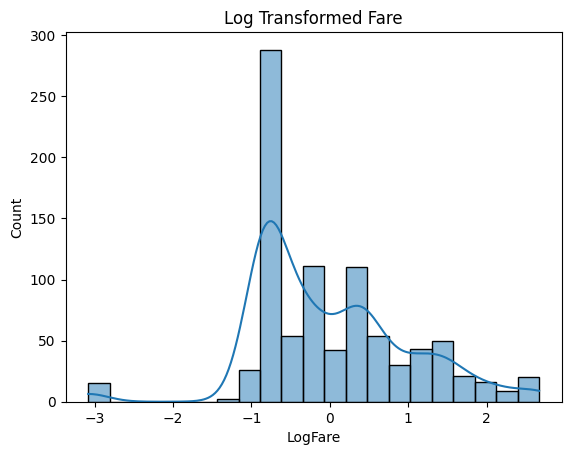

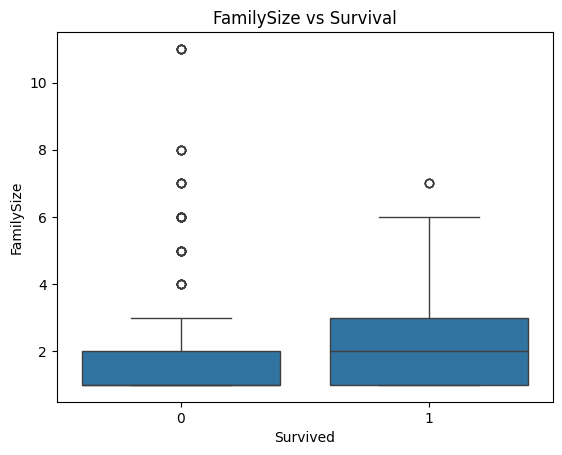

In [ ]:
from sklearn.preprocessing import StandardScaler

# Load cleaned
df = pd.read_csv('../data/train_cleaned.csv')

# Derived features
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Title extraction
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# Age groups
bins = [0, 12, 19, 59, np.inf]
labels = ['Child', 'Teen', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Fare per person
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

# Interaction features
df['Pclass_Fare'] = df['Pclass'] * df['Fare']
df['Age_Title'] = df['Age'] * (df['Title'] == 'Mr').astype(int)

# Encoding
categorical = ['Sex', 'Embarked', 'Title', 'AgeGroup']
df = pd.get_dummies(df, columns=categorical, drop_first=True)

# Transformations
df['LogFare'] = np.log1p(df['Fare'])
scaler = StandardScaler()
df[['Age', 'Fare', 'LogFare']] = scaler.fit_transform(df[['Age', 'Fare', 'LogFare']])

# Visualizations
sns.histplot(df['LogFare'], kde=True)
plt.title('Log Transformed Fare')
plt.show()

sns.boxplot(x='Survived', y='FamilySize', data=df)
plt.title('FamilySize vs Survival')
plt.show()

# Drop unnecessary columns
df.drop(['Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

# Save engineered dataset for feature selection
df_fe = df.copy()
df_fe.to_csv('../data/train_engineered.csv', index=False)
print("Saved: ../data/train_engineered.csv")
print(df_fe.shape)

# Part 3: Feature Selection
Justifications: Dropped SibSp/Parch as redundant with FamilySize. Kept top features like Title_Mr (importance 0.15) for discrimination. RFE confirmed similar selection. Dropped low-importance like CabinMissing (0.01)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

# Load engineered dataset saved from Part 2
df = pd.read_csv('../data/train_engineered.csv')

X = df.drop('Survived', axis=1)
y = df['Survived']

# Correlation matrix (numeric only for safety)
corr_matrix = X.select_dtypes(include='number').corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Drop redundant: SibSp and Parch are captured by FamilySize
X = X.drop(['SibSp', 'Parch'], axis=1)

# Feature Importance via Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

# Visual
plt.figure(figsize=(10, 6))
plt.barh(importances.index[:15], importances.values[:15])
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# RFE
rfe = RFE(rf, n_features_to_select=10)
rfe.fit(X, y)
selected = X.columns[rfe.support_]
print("Selected via RFE:", selected.tolist())

# Final selected features (top 10 by importance)
selected_features = importances.index[:10].tolist()
print("Final selected features:", selected_features)

ValueError: could not convert string to float: 'Braund, Mr. Owen Harris'